<a href="https://colab.research.google.com/github/jittuganissy/Coding/blob/main/car_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving car image.jpeg to car image (5).jpeg

0: 384x640 9 persons, 18 cars, 2 motorcycles, 11 buss, 96.5ms
Speed: 2.3ms preprocess, 96.5ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


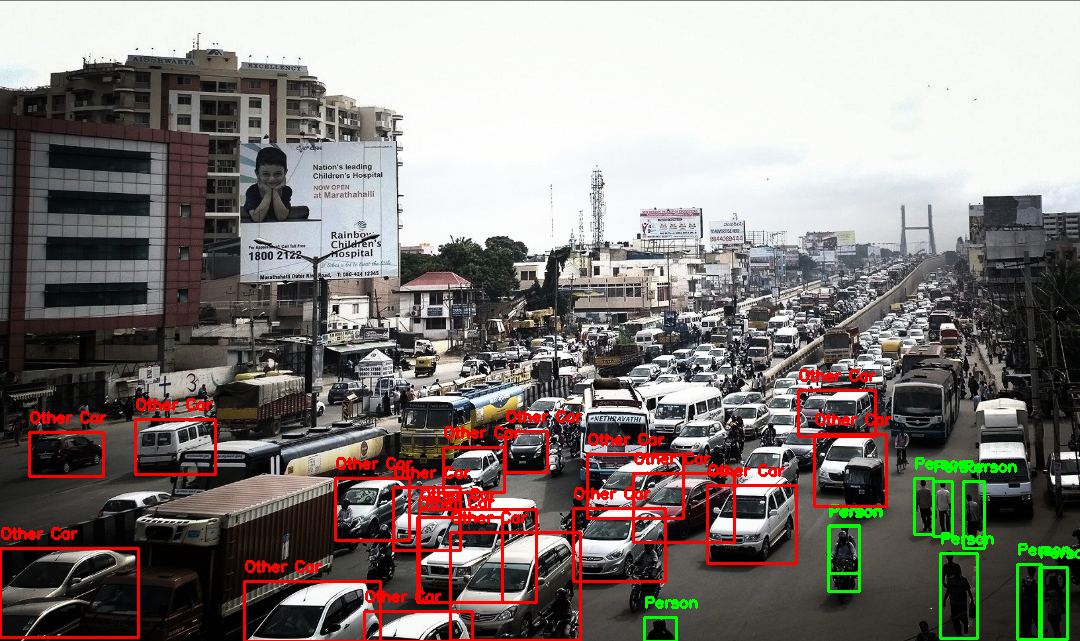

Total Persons Detected: 9
Total Cars Detected: 18
Detection and display took: 0.16 seconds


In [20]:
!pip install ultralytics opencv-python
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from google.colab import files
import time

# Load the YOLO model
model = YOLO("yolov8n.pt")

uploaded = files.upload()

# Get the filename of the uploaded image
if uploaded:
    img_name = list(uploaded.keys())[0]

    # Read the image using OpenCV
    image = cv2.imread(img_name)

    if image is None:
        print(f"Error: Could not read image {img_name}. Please ensure it's a valid image file.")
    else:
        start_time = time.time()

        # Perform inference with the YOLO model
        results = model(image)

        car_count = 0
        person_count = 0

        # Process the detection results
        for result in results:
            # Iterate through detected bounding boxes
            for box in result.boxes:
                cls = int(box.cls[0]) # Class ID
                x1, y1, x2, y2 = map(int, box.xyxy[0]) # Bounding box coordinates

                # Class 0 is 'person'
                if cls == 0:
                    person_count += 1
                    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2) # Green rectangle
                    cv2.putText(image, "Person", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

                # Class 2 is 'car'
                elif cls == 2:
                    car_count += 1

                    # Extract the car region for color detection
                    car_crop = image[y1:y2, x1:x2]
                    hsv = cv2.cvtColor(car_crop, cv2.COLOR_BGR2HSV)

                    # Define range for blue color in HSV
                    blue_lower = np.array([100, 50, 50])
                    blue_upper = np.array([140, 255, 255])

                    # Create a mask for blue pixels
                    mask = cv2.inRange(hsv, blue_lower, blue_upper)
                    blue_pixels = cv2.countNonZero(mask)

                    # Calculate ratio of blue pixels to total pixels in the car region
                    total_pixels = car_crop.shape[0] * car_crop.shape[1]
                    ratio = blue_pixels / (total_pixels + 1e-6) # Add small epsilon to avoid division by zero

                    if ratio > 0.15: # Threshold for considering it a blue car
                        color_name = "Blue Car"
                        rect_color = (255, 0, 0) # Red rectangle for blue cars
                    else:
                        color_name = "Other Car"
                        rect_color = (0, 0, 255) # Blue rectangle for other cars

                    cv2.rectangle(image, (x1, y1), (x2, y2), rect_color, 2)
                    cv2.putText(image, color_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, rect_color, 2)

        end_time = time.time()
        elapsed_time = end_time - start_time

        # Display the annotated image
        cv2_imshow(image)

        # Print counts
        print(f"Total Persons Detected: {person_count}")
        print(f"Total Cars Detected: {car_count}")
        print(f"Detection and display took: {elapsed_time:.2f} seconds")
else:
    print("No image file was uploaded.")